# 03 Transparency & Explainability
**Owner:** Çağrı

This notebook provides global and local explanations for the model's predictions using SHAP and LIME. It also introduces the Dual-View output (Instructor vs. Student) and explores the trade-off between Transparency and Privacy.


In [1]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))

import joblib
import pandas as pd
import shap
import matplotlib.pyplot as plt

from src.explainability import (
    build_shap_explainer, plot_global_importance,
    explain_instance_instructor, explain_instance_student,
    build_lime_explainer, explain_lime_instance
)
from src.privacy import suppress_sensitive_from_explanation

## 1. Load Artifacts


In [2]:
data_dir = Path.cwd().parent / 'data'
model = joblib.load(data_dir / 'base_model.pkl')
X_train = joblib.load(data_dir / 'X_train.pkl')
X_test = joblib.load(data_dir / 'X_test.pkl')
y_test = joblib.load(data_dir / 'y_test.pkl')

print("Model and data loaded.")

Model and data loaded.


## 2. Global Explanations (SHAP)


In [3]:
explainer = build_shap_explainer(model, X_train)

# We compute shap values for a sample to avoid long computation times
shap_sample = X_test.sample(200, random_state=42)
shap_values = explainer(shap_sample)

 98%|===================| 394/400 [00:11<00:00]       

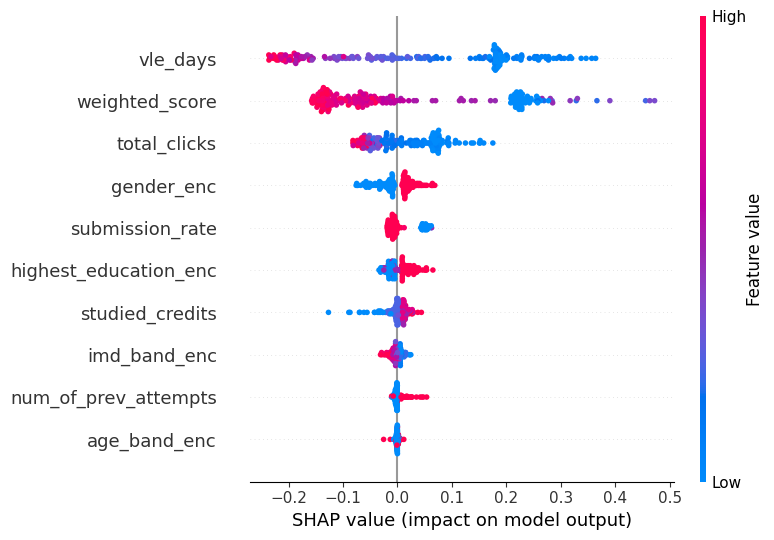

In [4]:
# Summary Plot (Global Importance)
plot_global_importance(explainer, shap_sample, max_display=10)

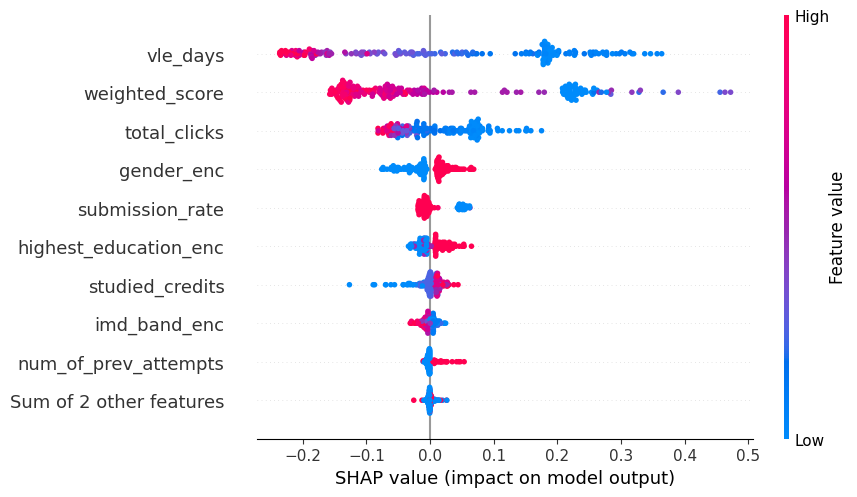

In [5]:
# Beeswarm plot showing positive/negative effects
shap.plots.beeswarm(shap_values[:, :, 1], max_display=10)

## 3. Local Explanations (Dual-View)
Selecting an at-risk student to show the difference between Instructor View and Student View.


--- Instructor View for Student 30849 ---
=== INSTRUCTOR VIEW ===
Risk Score: 0.543 (base = 0.457)


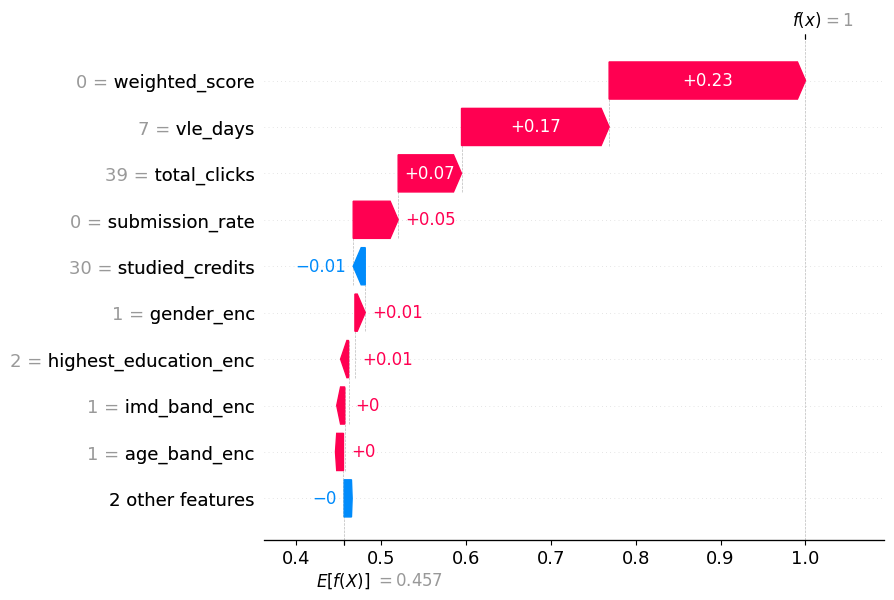

In [6]:
# Find an at-risk student (target = 1)
at_risk_idx = y_test[y_test == 1].index[0]
instance = X_test.loc[at_risk_idx]
feature_names = X_test.columns.tolist()

print(f"--- Instructor View for Student {at_risk_idx} ---")
explain_instance_instructor(explainer, instance, feature_names)
print("\n")

In [7]:
print(f"--- Student View for Student {at_risk_idx} ---")
student_text = explain_instance_student(explainer, instance, feature_names, top_n=3)
print(student_text)

--- Student View for Student 30849 ---
=== YOUR RISK SUMMARY ===
  - weighted_score: increasing your risk
  - vle_days: increasing your risk
  - total_clicks: increasing your risk

Note: This is a decision-support tool. Speak to your advisor for guidance.


## 4. Alternative Local Explanation (LIME)
Comparing SHAP with LIME for the same instance.


--- LIME Explanation for Student 30849 ---


c:\Users\cagri\OneDrive\Desktop\Sabancı-CS-Master\CS540\Group-Project\code\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


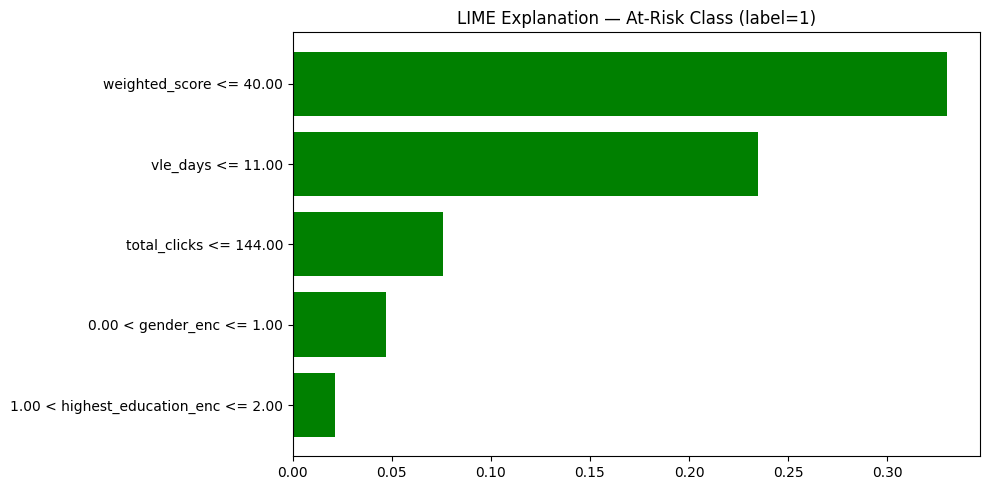

In [ ]:
lime_explainer = build_lime_explainer(X_train, feature_names)
print(f"--- LIME Explanation for Student {at_risk_idx} ---")
explain_lime_instance(lime_explainer, model, instance, num_features=5

## 5. Trade-off: Transparency vs Privacy
If sensitive attributes (like imd_band or gender) show up in explanations, they might leak demographic biases directly to the end-user. We can suppress these using `suppress_sensitive_from_explanation`.


In [9]:
sensitive_enc = ['imd_band_enc', 'gender_enc', 'disability_enc', 'age_band_enc']

# Get raw SHAP values for the instance
instance_shap_values = explainer.shap_values(instance)[1] # index 1 for positive class
shap_series = pd.Series(instance_shap_values, index=feature_names)

print("Original top 5 features by absolute SHAP value:")
print(shap_series.abs().sort_values(ascending=False).head(5))

print("\nMasking sensitive features...")
safe_shap = suppress_sensitive_from_explanation(shap_series, sensitive_enc)
print("\nSafe top 5 features (sensitive ones removed/zeroed):")
print(safe_shap.abs().sort_values(ascending=False).head(5))

ValueError: Length of values (2) does not match length of index (11)